In [ ]:
import math
import tqdm
import string
import time
import random
import numpy as np
import pandas as pd
import re, os, random
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Set device based on GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
torch.manual_seed(10701)
random.seed(10701)
np.random.seed(10701)

In [ ]:
AA_VOCAB  = list('ACDEFGHIKLMNPQRSTVWXY')
SS8_VOCAB = ['C', 'B', 'E', 'G', 'I', 'H', 'S', 'T']
MAX_LEN   = 700

class ProteinDataset(Dataset):
    def __init__(self, df, max_len=MAX_LEN):
        self.df      = df.reset_index(drop=True)
        self.max_len = max_len
        self.aa_map  = {c: i for i, c in enumerate(AA_VOCAB)}
        self.ss_map  = {c: i for i, c in enumerate(SS8_VOCAB)}

    def __len__(self):
        return len(self.df)

    def encode(self, seq, vocab_map):
        arr = np.zeros(self.max_len, dtype=np.int64)
        for i, ch in enumerate(seq[:self.max_len]):
            if ch in vocab_map:
                arr[i] = vocab_map[ch]
        return arr

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        X      = self.encode(row['input'], self.aa_map)
        y      = self.encode(row['dssp8'], self.ss_map)
        length = min(len(row['input']), self.max_len)
        mask   = np.zeros(self.max_len, dtype=np.float32)
        mask[:length] = 1.0
        return (torch.tensor(X),
                torch.tensor(y),
                torch.tensor(mask))

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/2025-26/10701/train_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/2025-26/10701/test_data.csv')

train_dataset = ProteinDataset(train_df)
test_dataset  = ProteinDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [ ]:
class RNN(nn.Module):
    def __init__(self, vocab_size, input_size, hidden_size, output_size, batch_size):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.batch_size = batch_size

        # Initialize embeddings, model layers, layer normalization, and activation function
        self.embedding = torch.nn.Embedding(num_embeddings=vocab_size, embedding_dim=input_size, padding_idx=0)
        self.input_to_hidden = torch.nn.Linear(input_size, hidden_size)
        self.hidden_to_hidden = torch.nn.Linear(hidden_size, hidden_size)
        self.hidden_to_out = torch.nn.Linear(hidden_size, output_size)

        self.layer_norm = torch.nn.LayerNorm(hidden_size)
        self.tanh = torch.nn.Tanh()
        self.softmax = torch.nn.Softmax()


    def forward(self, input: torch.Tensor, hidden: torch.Tensor) -> torch.Tensor:
        # Implement forward pass including layer normalization

        h = hidden
        e = self.embedding(input)
        y = []
        for t in range(e.shape[1]):
            x_t = e[:, t, :]
            h = self.tanh(self.layer_norm(self.input_to_hidden(x_t) + self.hidden_to_hidden(h)))
            y_t = self.softmax(self.hidden_to_out(h))
            y.append(y_t)

        return torch.stack(y, dim=1)

    def init_hidden(self, batch_size, device):
      h0 = torch.zeros(batch_size, self.hidden_size, device=device)
      return h0

In [ ]:
# def train(data_loader, model, criterion, optimizer):
#     test_avg_loss = 0
#     num_correct = 0

#     total_samples = 0

#     # Set model to training mode
#     model.train()

#     for samples, labels in tqdm.tqdm(data_loader, leave=False):
#         # Convert labels to LongTensors and move to device
#         labels = labels.long().to(device)
#         # labels = labels.to(device)

#         # samples = torch.tensor(samples).to(device)
#         samples = samples.to(device)

#         total_samples += labels.size(0)

#         # Initialize hidden state
#         h0 = model.init_hidden().to(device)

#         # print(f"Labels dtype = {labels.dtype}, Samples dtype = {samples.dtype}, h0 dtype = {h0.dtype}")

#         # Perform forward pass and calculate avg loss over all time steps
#         out = model.forward(samples, h0)

#         # num_tokens = out.shape[1]
#         # loss = 0
#         # for t in range(out.shape[1]):
#         #     loss += criterion(out[:, t, :], labels)
#         # loss = criterion(out, labels)

#         loss = 0
#         B, L, C = out.shape

#         out = out.view(B * L, C)
#         labels = labels.view(B * L)
#         mask = mask.view(B * L)

#         loss = criterion(out, labels)          # (B*L)
#         loss = loss * mask                     # ignore padding
#         loss = loss.sum() / mask.sum()         # average over valid tokens

#         # preds = torch.argmax(out[:, -1, :], dim=-1)

#         preds = torch.argmax(out, dim=-1)   # (B, L)

#         correct = ((preds == labels) * mask).sum()
#         total = mask.sum()

#         num_correct += correct.item()
#         total_tokens += total.item()

#         test_avg_loss += loss.item() * labels.size(0)

#         # Calculate number of correct predictions
#         acc = torch.sum(preds == labels)
#         num_correct += acc

#         # Backward pass, update weights, and zero gradients
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#     # Uncomment the line below once the training loop is implemented to print
#     # the loss and accuracy at the end of each epoch

#     total_samples_loss = total_samples * num_tokens
#     print(f"Total Samples = {total_samples}, len(data_loader) = {len(data_loader)}")
#     print(f"Train loss: {test_avg_loss/total_samples_loss} | Accuracy: {num_correct/total_samples}")
#     train_loss = test_avg_loss/total_samples_loss
#     train_acc = num_correct/total_samples
#     return train_loss, train_acc

In [ ]:
def train(data_loader, model, criterion, optimizer, device):
    model.train()

    total_loss = 0
    total_tokens = 0
    num_correct = 0

    for samples, labels, mask in tqdm.tqdm(data_loader, leave=False):
        samples = samples.to(device)
        labels = labels.to(device)
        mask = mask.to(device)

        B, L = samples.shape

        # h0 = model.init_hidden().to(device)
        B = samples.size(0)
        h0 = model.init_hidden(B, device)

        out = model(samples, h0)   # (B, L, C)

        # reshape
        out_flat = out.view(-1, out.shape[-1])   # (B*L, C)
        labels_flat = labels.view(-1)            # (B*L)
        mask_flat = mask.view(-1)                # (B*L)

        loss = criterion(out_flat, labels_flat)  # (B*L)
        loss = loss * mask_flat
        loss = loss.sum() / mask_flat.sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * mask_flat.sum().item()
        total_tokens += mask_flat.sum().item()

        preds = torch.argmax(out, dim=-1)
        num_correct += ((preds == labels) * mask).sum().item()

    train_loss = total_loss / total_tokens
    train_acc = num_correct / total_tokens
    print(f"Train loss: {train_loss}")
    print(f"Accuracy: {train_acc}")

    return train_loss, train_acc

In [ ]:
# def train(data_loader, model, criterion, optimizer, device):
#     train_avg_loss = 0
#     num_correct = 0
#     total_residues = 0

#     model.train()  # Set model to training mode

#     # Implement training loop
#     for X, y, mask in tqdm(data_loader, leave=False):
#         optimizer.zero_grad()
#         X = X.to(device=device, dtype=torch.long)
#         y = y.to(device=device, dtype=torch.long)
#         mask = mask.to(device=device, dtype=torch.long)

#         # Perform forward pass
#         y_hat = model.forward(X)
#         pred = y_hat.argmax(dim=-1).to(dtype=torch.long)

#         # Calculate loss at every position and ignore padding
#         loss = criterion(y_hat.reshape(-1, NUM_CLASSES), y.reshape(-1))
#         loss = (loss * mask.reshape(-1)).sum() / mask.sum()

#         # Calculate number of correct predictions (ignore masked values)
#         corr = torch.sum((y == pred) * mask)
#         total_residues += mask.sum().item()

#         # Backward pass, update weights, and zero gradients
#         loss.backward()
#         optimizer.step()


#         num_correct += corr.item()
#         train_avg_loss += loss.item()


#     # print the loss and accuracy at the end of each epoch
#     final_loss = train_avg_loss/len(data_loader)
#     final_acc = num_correct/total_residues
#     print(f"Train loss: {final_loss} | Accuracy: {final_acc}")

#     return final_loss, final_acc

In [ ]:
# def test(data_loader, rnn, criterion):
#     test_avg_loss = 0
#     num_correct = 0

#     total_samples = 0

#     # Set model to eval mode
#     rnn.eval()

#     # Implement testing loop
#     # Hint: Do we want to update gradients when testing?
#     with torch.no_grad():
#         for samples, labels in tqdm.tqdm(data_loader, leave=False):
#             # Convert labels to LongTensors and move to device
#             labels = labels.long().to(device)

#             # Initialize hidden state
#             h0 = rnn.init_hidden().to(device)

#             samples = samples.to(device)

#             total_samples += labels.size(0)

#             # Perform forward pass and calculate avg loss over all time steps
#             out = rnn.forward(samples, h0)
#             preds = torch.argmax(out[:, -1, :], dim=-1)

#             num_tokens = out.shape[1]
#             loss = 0
#             for t in range(out.shape[1]):
#                 loss += criterion(out[:, t, :], labels)

#             test_avg_loss += loss * labels.size(0)

#             # Calculate number of correct predictions
#             acc = torch.sum(preds == labels)
#             num_correct += acc

#         total_samples_loss = total_samples * num_tokens
#         # Uncomment the line below once the training loop is implemented to print
#         # the loss and accuracy at the end of each epoch
#         print(f"Test loss: {test_avg_loss/total_samples_loss} | Accuracy: {num_correct/total_samples}")


#         test_loss = test_avg_loss / total_samples_loss
#         test_acc = num_correct / total_samples
#         return test_loss, test_acc

In [ ]:
def test(data_loader, model, criterion, device):
    total_loss = 0
    total_tokens = 0
    num_correct = 0

    # Set model to eval mode
    model.eval()

    # Implement testing loop
    # Hint: Do we want to update gradients when testing?
    with torch.no_grad():
        for samples, labels, mask in tqdm.tqdm(data_loader, leave=False):
          samples = samples.to(device)
          labels = labels.to(device)
          mask = mask.to(device)

          B, L = samples.shape

          # h0 = model.init_hidden().to(device)
          B = samples.size(0)
          h0 = model.init_hidden(B, device)

          out = model(samples, h0)   # (B, L, C)

          # reshape
          out_flat = out.view(-1, out.shape[-1])   # (B*L, C)
          labels_flat = labels.view(-1)            # (B*L)
          mask_flat = mask.view(-1)                # (B*L)

          loss = criterion(out_flat, labels_flat)  # (B*L)
          loss = loss * mask_flat
          loss = loss.sum() / mask_flat.sum()

          total_loss += loss.item() * mask_flat.sum().item()
          total_tokens += mask_flat.sum().item()

          preds = torch.argmax(out, dim=-1)
          num_correct += ((preds == labels) * mask).sum().item()

    test_loss = total_loss / total_tokens
    test_acc = num_correct / total_tokens
    print(f"Test loss: {test_loss}")
    print(f"Accuracy: {test_acc}")
    return test_loss, test_acc

In [ ]:
# def test(data_loader, model, criterion, device):
#     test_avg_loss = 0
#     num_correct = 0
#     total_residues = 0

#     model.eval() # Set model to eval mode

#     # Implement testing loop
#     with torch.no_grad():
#       for X, y, mask in tqdm(data_loader, leave=False):
#         X = X.to(device=device, dtype=torch.long)
#         y = y.to(device=device, dtype=torch.long)
#         mask = mask.to(device=device, dtype=torch.long)

#         # Perform forward pass
#         y_hat = model.forward(X)
#         pred = y_hat.argmax(dim=-1).to(dtype=torch.long)

#         # Calculate loss at every position and ignore padding
#         loss = criterion(y_hat.reshape(-1, NUM_CLASSES), y.reshape(-1))
#         loss = (loss * mask.reshape(-1)).sum() / mask.sum()

#         # Calculate number of correct predictions (ignore masked values)
#         corr = torch.sum((y == pred) * mask)
#         total_residues += mask.sum().item()

#         num_correct += corr.item()
#         test_avg_loss += loss.item()

#     # print the loss and accuracy at the end of each epoch
#     final_loss = test_avg_loss/len(data_loader)
#     final_acc = num_correct/total_residues
#     print(f"Test loss: {final_loss} | Accuracy: {final_acc}")

#     return final_loss, final_acc

In [ ]:
def run(num_epochs, train_dataloader, test_dataloader, rnn, criterion, optimizer):
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        # Perform one epoch of training and testing
        train_loss, train_acc = train(train_dataloader, rnn, criterion, optimizer, device)
        test_loss, test_acc = test(test_dataloader, rnn, criterion, device)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

    return train_losses, test_losses, train_accs, test_accs

In [ ]:
def plot_losses(epochs, train_losses, test_losses):
    plt.plot(epochs, train_losses, label="Train")
    plt.plot(epochs, test_losses, label="Validation")
    plt.title("Loss Over Epochs (RNN)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    plt.savefig('/content/drive/MyDrive/2025-26/10701/losses_plot.png')

In [ ]:
def plot_accs(epochs, train_accs, test_accs):
    plt.plot(epochs, train_accs, label="Train")
    plt.plot(epochs, test_accs, label="Validation")
    plt.title("Accuracy Over Epochs (RNN)")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
    plt.savefig('/content/drive/MyDrive/2025-26/10701/accuracies_plot.png')

In [ ]:
def main(
    # Hyperparameters
    vocabulary_size = 20000,
    batch_size = 128,
    input_size = 64,
    hidden_size = 128,
    max_review_length = MAX_LEN,
    lr = 1e-4,
    num_epochs = 10,
    num_classes = 2
):
    input_size = MAX_LEN
    num_train_samples = 10790
    num_test_samples = 432
    AA_vocab_size = len(AA_VOCAB) # 21
    SS8_vocab_size = len(SS8_VOCAB) # 8
    num_classes = 8 # using SS8?

    # Initialize model
    model = RNN(AA_vocab_size, MAX_LEN, hidden_size, num_classes, batch_size)
    model.to(device)

    # Initialize loss function and optimizer
    loss_fn = nn.CrossEntropyLoss(reduction='none')
    optim = torch.optim.Adam(model.parameters(), lr)

    # Run training and testing
    train_losses, test_losses, train_accs, test_accs = run(num_epochs, train_loader, test_loader, model, loss_fn, optim)
    # run(num_epochs, train_dataloader, test_dataloader, model, loss_fn, optim)

    # print(f"Train losses = {train_losses}")
    # print(f"Test losses = {test_losses}")

    plot_losses(list(range(num_epochs)), train_losses, test_losses)
    return train_losses, test_losses

Epoch 0


  0%|          | 0/338 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Train loss: 1.8775038575120273
Accuracy: 0.4071973322096304


Test loss: 1.8592879030676714
Accuracy: 0.4135562686483139
Epoch 1


Train loss: 1.8345328222172173
Accuracy: 0.43794033181322384


...

Test loss: 1.833613627457118
Accuracy: 0.43314755390418286
Epoch 8


Train loss: 1.8099703810746606
Accuracy: 0.4587507572687699


Test loss: 1.8314340003298282
Accuracy: 0.4358779485447278
Epoch 9


Train loss: 1.8081243108991747
Accuracy: 0.46042235115742264


Test loss: 1.832994035089203
Accuracy: 0.4341538591454146


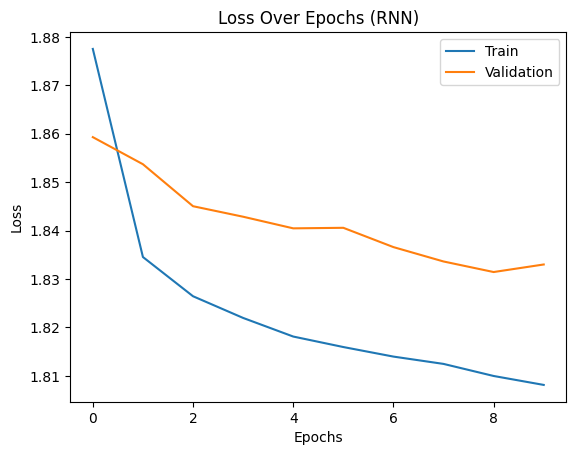

([1.8775038575120273,
  1.8345328222172173,
  1.826435631592815,
  1.8219552053392907,
  1.8181138917028,
  1.815946932507051,
  1.8139743300875228,
  1.8124635855343596,
  1.8099703810746606,
  1.8081243108991747],
 [1.8592879030676714,
  1.8536944046598938,
  1.8450255269449063,
  1.8428545367245952,
  1.8404552585261367,
  1.8405664102327701,
  1.83658261952761,
  1.833613627457118,
  1.8314340003298282,
  1.832994035089203])

<Figure size 640x480 with 0 Axes>

In [ ]:
main()